# 데이터분석 개요 및 기초 통계 Day 2 종합실습

| 항목 | 내용 |
|---|---|
| 교육일자 | 2026년 7월 21일 |
| 과정 | SKALA 4기 데이터분석 및 AIOps |
| 메인교수 | 이은호 |
| 실습교수 | 김영희 |

## 학습 목표

① 결측치와 이상치의 원인을 확인하고 적절한 처리 방법을 선택한다.<br>
② 데이터 스케일링, 분포 변환과 범주형 변수 인코딩을 수행한다.<br>
③ 상관계수와 회귀분석 결과를 계산하고 해석한다.<br>
④ 잔차도와 VIF를 사용해 회귀모형의 기본 가정을 점검한다.<br>

## 실습 진행 방법

① 환경 설정 셀을 먼저 실행한다.<br>
② 각 실습의 `TODO` 부분을 작성한다.<br>
③ 실행 결과를 확인한 뒤 정답 셀과 비교한다.<br>
④ 심화 실습은 기본 실습을 마친 뒤 선택해서 수행한다.<br>



In [133]:
# 환경 설정: 이 셀을 먼저 실행합니다.
!pip install -q koreanize-matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from scipy import stats
import statsmodels.api as sm

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 4)

try:
    titanic = sns.load_dataset("titanic")
    tips = sns.load_dataset("tips")
    iris = sns.load_dataset("iris")
except Exception as exc:
    raise RuntimeError(
        "예제 데이터 다운로드에 실패했습니다. 인터넷 연결을 확인한 뒤 다시 실행하세요."
    ) from exc

print("환경 설정 완료")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)


환경 설정 완료
NumPy: 2.0.2
pandas: 2.2.2


## 1. 결측치 처리

결측치는 값이 관측되지 않아 비어 있는 상태이다.<br> 처리 방법을 정하기 전에 결측 건수와 발생 원인을 먼저 확인해야 한다.

| 처리 방법 | 적용 기준 | 주요 함수 |
|---|---|---|
| 행 또는 열 제거 | 결측 비율이 낮고 제거 후 데이터가 충분할 때 | `dropna()` |
| 대표값 대체 | 수치형 변수의 일반적인 값을 사용할 때 | `fillna()` |
| 직전값 대체 | 이전 상태가 다음 시점까지 유지된다고 볼 때 | `ffill()` |
| 선형 보간 | 값이 시간 흐름에 따라 연속적으로 변할 때 | `interpolate()` |
| 별도 범주 부여 | 범주형 결측 자체에 의미가 있을 때 | `"Unknown"` |

`0`은 결측치가 아니다. 값이 없음을 뜻하는 실제 관측값일 수 있으므로 업무 의미를 확인한 뒤 처리한다.

### 처리 순서

① 결측 건수와 비율을 확인한다.<br>
② 결측이 발생한 이유를 검토한다.<br>
③ 제거 또는 대체 방법을 선택한다.<br>
④ 처리 전후의 평균, 표준편차와 분포를 비교한다.<br>


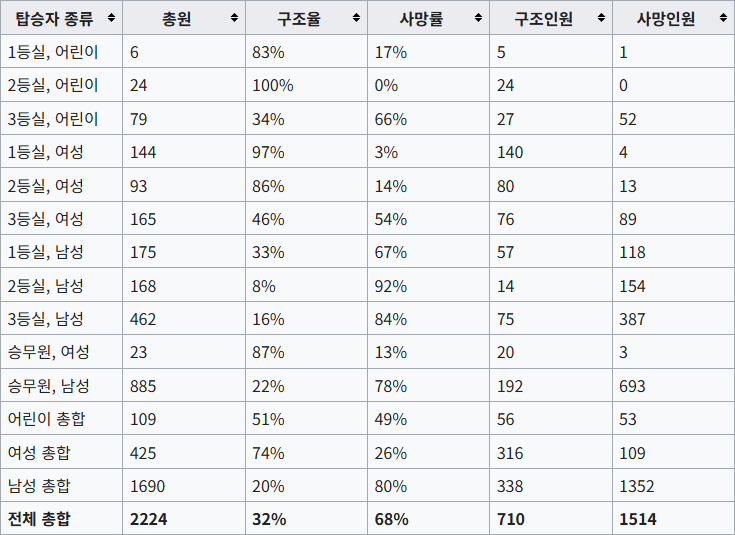
<br>참고: https://ko.wikipedia.org/wiki/타이타닉호_침몰_사고

In [134]:
# 예시: [1, 결측, 결측, 7]을 세 가지 방법으로 처리합니다.
s = pd.Series([1, np.nan, np.nan, 7])

demo = pd.DataFrame({
    "원본": s,
    "평균 대체": s.fillna(s.mean()),
    "직전값 대체": s.ffill(),
    "선형 보간": s.interpolate(),
})
demo


,원본,평균 대체,직전값 대체,선형 보간
0,1.0,1.0,1.0,1.0
1,NaN,4.0,1.0,3.0
2,NaN,4.0,1.0,5.0
3,7.0,7.0,7.0,7.0


### 1.1 기초 실습: 나이 결측치 처리 방법 비교

`titanic` 데이터의 `age` 변수에는 결측값이 포함되어 있다.<br> 평균 대체, 중앙값 대체와 행 제거를 적용한 뒤 평균과 표준편차를 비교한다.

#### 수행 절차

① 원본에서 평균과 표준편차를 계산한다.<br>
② 평균과 중앙값으로 결측치를 각각 대체한다.<br>
③ 결측 행을 제거한 결과도 계산한다.<br>
④ 결과를 표로 정리하고 표준편차가 어떻게 달라지는지 확인한다.<br>


In [135]:
age = titanic["age"]

# TODO: 세 가지 방법 적용 후 mean/std 비교 표 만들기

result_df = pd.DataFrame({
    "원본": [age.mean(), age.std()],
    "평균 대체": [age.fillna(age.mean()).mean(), age.fillna(age.mean()).std()],
    "중앙값 대체": [
        age.fillna(age.median()).mean(), 
        age.fillna(age.median()).std()
    ],
    "행 제거" : [age.dropna().mean(), age.dropna().std()]
})
result_df

,원본,평균 대체,중앙값 대체,행 제거
0,29.699118,29.699118,29.361582,29.699118
1,14.526497,13.002015,13.019697,14.526497


In [136]:
#@title 정답 확인 { display-mode: "form" }
age = titanic["age"]

results = pd.DataFrame({
    "원본(결측 제외)": [age.mean(), age.std()],
    "평균 대체": [
        age.fillna(age.mean()).mean(),
        age.fillna(age.mean()).std(),
    ],
    "중앙값 대체": [
        age.fillna(age.median()).mean(),
        age.fillna(age.median()).std(),
    ],
    "행 제거": [age.dropna().mean(), age.dropna().std()],
}, index=["평균", "표준편차"]).round(3)

display(results)

# 평균 대체는 평균을 유지하지만 같은 값을 반복해서 넣으므로
# 표준편차가 작아질 수 있습니다.


,원본(결측 제외),평균 대체,중앙값 대체,행 제거
평균,29.699,29.699,29.362,29.699
표준편차,14.526,13.002,13.020,14.526


### 1.2 응용 실습: 시계열 결측치 처리

다음 데이터는 14일 동안의 카페 매출이다.<br> 매출은 상승 흐름을 보이므로 단순한 평균 대체보다 시간 순서를 반영하는 방법이 적절하다.

#### 수행 절차

① `ffill()`로 직전값을 채운다.<br>
② `interpolate()`로 결측 구간을 선형 보간한다.<br>
③ 원본 관측값과 두 처리 결과를 한 그래프에 표시한다.<br>
④ 상승 구간에서 어떤 방법이 더 자연스러운지 설명한다.<br>


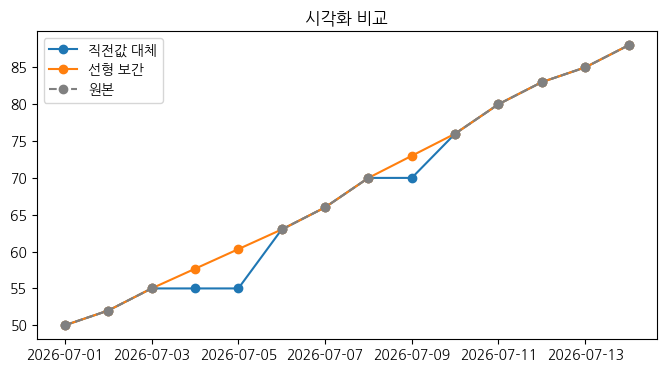

In [137]:
dates = pd.date_range("2026-07-01", periods=14)
sales = pd.Series([50, 52, 55, np.nan, np.nan, 63, 66, 70, np.nan, 76, 80, 83, 85, 88],
                  index=dates)

# TODO: 두 방식 대체 + 시각화 비교
filled_ffill = sales.ffill()
filled_bfill = sales.interpolate()

plt.plot(filled_ffill, label="직전값 대체", marker="o")
plt.plot(filled_bfill, label="선형 보간", marker="o")
plt.plot(sales, label="원본", marker="o", linestyle="--", color="gray")
plt.title("시각화 비교")
plt.legend()
plt.show()

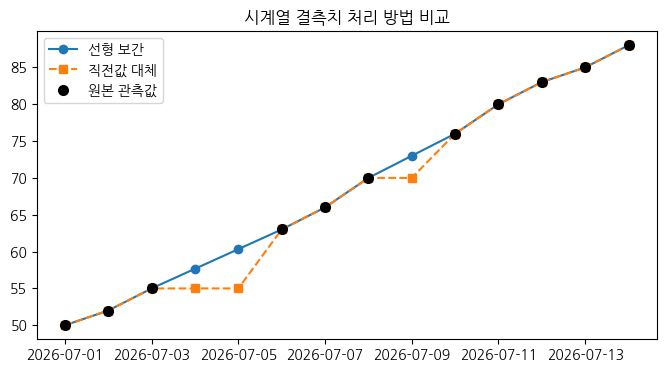

직전값 대체는 이전 상태가 유지된다고 가정합니다.
선형 보간은 두 관측값 사이의 변화 흐름을 반영합니다.


In [138]:
#@title 정답 확인 { display-mode: "form" }
filled_ffill = sales.ffill()
filled_interp = sales.interpolate()

plt.plot(filled_interp, "o-", label="선형 보간")
plt.plot(filled_ffill, "s--", label="직전값 대체")
plt.plot(sales, "ko", markersize=7, label="원본 관측값")
plt.title("시계열 결측치 처리 방법 비교")
plt.legend()
plt.show()

print("직전값 대체는 이전 상태가 유지된다고 가정합니다.")
print("선형 보간은 두 관측값 사이의 변화 흐름을 반영합니다.")


### 1.3 심화 실습: 결측 발생 원인과 대체 편향

결측치는 발생 방식에 따라 분석 결과에 미치는 영향이 달라진다.

| 유형 | 의미 | 예시 |
|---|---|---|
| MCAR | 다른 변수나 결측값 자체와 관계없이 무작위로 발생 | 설문지 일부가 우연히 분실됨 |
| MAR | 다른 관측 변수와 관련되어 발생 | 고연령층에서 소득 무응답이 많음 |
| MNAR | 결측값 자체의 크기와 관련되어 발생 | 고소득자일수록 소득 응답을 피함 |

평균 대체는 구현이 간단하지만 분산과 변수 간 관계를 약화할 수 있다. 특히 MNAR에서는 평균과 상관계수가 크게 왜곡될 수 있다.

#### 수행 절차

① 키와 몸무게가 관련된 데이터 1,000건을 생성한다.<br>
② 몸무게의 30%를 무작위 결측으로 만든다.<br>
③ 몸무게 상위 30%를 결측으로 만든다.<br>
④ 두 경우에 평균 대체를 적용하고 원본과 평균 및 상관계수를 비교한다.<br>


In [139]:
n = 1000
x = np.random.normal(170, 7, n)                       # 키
y = 0.9*x - 90 + np.random.normal(0, 4, n)            # 몸무게 (corr ≈ 0.8)
df0 = pd.DataFrame({"x": x, "y": y})

# TODO: MCAR / MNAR 결측 생성 → 평균 대체 → 평균,상관 비교표

#1. 키 몸무게 관련 데이터 생성
df0.head()

,x,y
0,173.476999,71.726721
1,169.032150,65.827470
2,174.533820,67.318959
3,180.661209,70.007341
4,168.360926,64.317727


In [140]:
# 2. 몸무게 30% 결측 생성 (MCAR)
df_mcar = df0.copy()
mcar_idx = np.random.choice(df_mcar.index, size=int(len(df_mcar)*0.3), replace=False)
df_mcar.loc[mcar_idx, "y"] = np.nan
df_mcar.isnull().sum()

,0
x,0
y,300


In [141]:
df_mcar.describe()

,x,y
count,1000.000000,700.000000
mean,170.135324,63.597237
std,6.854512,7.317780
min,147.311129,44.735040
25%,165.466868,59.073554
50%,170.177104,63.439681
75%,174.535607,68.049202
max,196.969120,94.270515


In [142]:
# 3. 몸무게 상위 30% 결측 생성 (MNAR)
df_mnar = df0.copy()
mnar_idx = df_mnar[df_mnar["y"] > df_mnar["y"].quantile(0.7)].index
df_mnar.loc[mnar_idx, "y"] = np.nan
df_mnar.isnull().sum()

,0
x,0
y,300


In [143]:
df_mnar.describe()

,x,y
count,1000.000000,700.000000
mean,170.135324,59.802432
std,6.854512,4.891235
min,147.311129,43.661384
25%,165.466868,57.136217
50%,170.177104,60.687079
75%,174.535607,63.635574
max,196.969120,66.737172


In [144]:
# 4. mcar, mnar 결측치 처리 후 평균, 상관 비교
df_mcar_mean = df_mcar.fillna(df_mcar.mean())
df_mnar_mean = df_mnar.fillna(df_mnar.mean())
df_compare = pd.DataFrame({
    "원본": [df0["y"].mean(), df0["y"].std(), df0["x"].corr(df0["y"])],
    "MCAR 평균 대체": [df_mcar_mean["y"].mean(), df_mcar_mean["y"].std(), df_mcar_mean["x"].corr(df_mcar_mean["y"])],
    "MNAR 평균 대체": [df_mnar_mean["y"].mean(), df_mnar_mean["y"].std(), df_mnar_mean["x"].corr(df_mnar_mean["y"])],
}, index=["평균", "표준편차", "상관계수"]).round(3)
display(df_compare)

,원본,MCAR 평균 대체,MNAR 평균 대체
평균,63.405,63.597,59.802
표준편차,7.210,6.121,4.091
상관계수,0.833,0.707,0.453


In [145]:
#@title 정답 확인 { display-mode: "form" }
def impute_and_measure(df, mask, label):
    data = df.copy()
    data.loc[mask, "y"] = np.nan
    data["y"] = data["y"].fillna(data["y"].mean())

    return pd.Series({
        "Y 평균": data["y"].mean(),
        "corr(X,Y)": data["x"].corr(data["y"]),
    }, name=label)


mcar_mask = np.random.rand(n) < 0.30
mnar_mask = df0["y"] >= df0["y"].quantile(0.70)

report = pd.concat([
    pd.Series({
        "Y 평균": df0["y"].mean(),
        "corr(X,Y)": df0["x"].corr(df0["y"]),
    }, name="원본"),
    impute_and_measure(df0, mcar_mask, "MCAR 평균 대체"),
    impute_and_measure(df0, mnar_mask, "MNAR 평균 대체"),
], axis=1).T.round(3)

display(report)

print("MCAR에서는 평균이 비교적 유지되지만 상관은 약해질 수 있습니다.")
print("MNAR에서는 높은 값이 빠지므로 평균과 상관이 크게 왜곡될 수 있습니다.")


,Y 평균,"corr(X,Y)"
원본,63.405,0.833
MCAR 평균 대체,63.548,0.687
MNAR 평균 대체,59.802,0.453


MCAR에서는 평균이 비교적 유지되지만 상관은 약해질 수 있습니다.
MNAR에서는 높은 값이 빠지므로 평균과 상관이 크게 왜곡될 수 있습니다.


## 2. 이상치 처리

이상치는 다른 관측값과 크게 떨어진 값이다. 입력 오류일 수도 있지만 실제로 발생한 중요한 사례일 수도 있으므로 통계 기준만으로 바로 제거하지 않는다.

| 판단 방법 | 기준 | 특징 |
|---|---|---|
| 분위수 | 하위 5% 또는 상위 5% 등 | 업무 목적에 따라 범위를 정함 |
| IQR | `Q1 - 1.5×IQR` 미만 또는 `Q3 + 1.5×IQR` 초과 | 치우친 분포와 이상치에 비교적 강함 |
| Z-score | 일반적으로 `|Z| > 3` | 정규분포에 가까운 데이터에 적합 |
| 업무 규칙 | 허용 범위, 물리적 한계, 정책 기준 | 최종 판단에 반드시 필요 |

### 처리 순서

① 입력 오류인지 확인한다.<br>
② 실제 값이면 분석 목적상 포함할지 결정한다.<br>
③ 제거, 경계값 대체, 변환 또는 별도 분석을 선택한다.<br>
④ 처리 기준과 결과 변화를 기록한다.<br>


In [146]:
# 같은 데이터에 IQR 기준과 Z-score 기준을 적용합니다.
data = np.append(np.random.normal(100, 10, 200), [160, 165, 40])

z_score = np.abs(stats.zscore(data))

q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1
iqr_mask = (data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)

print("IQR 기준:", iqr_mask.sum(), "건")
print("|Z| > 3 기준:", (z_score > 3).sum(), "건")


IQR 기준: 3 건
|Z| > 3 기준: 3 건


### 2.1 기초 실습: Z-score로 이상치 찾기

`tips` 데이터의 `total_bill`에서 `|Z| > 3`인 행을 찾는다. Z-score는 각 값이 평균에서 표준편차 몇 배만큼 떨어져 있는지 나타낸다.

#### 수행 절차

① 평균과 표준편차로 Z-score를 직접 계산한다.<br>
② 절댓값이 3보다 큰 행을 선택한다.<br>
③ 탐지된 건수와 전체 행을 출력한다.<br>


In [147]:
tb = tips["total_bill"]

# TODO: z 직접 계산 → |z| > 3 행 출력

In [148]:
# 1. Z-score 직접 계산
tb_z = (tb - tb.mean()) / tb.std()
outliers = tb[np.abs(tb_z) > 3]
outliers

,total_bill
59,48.27
156,48.17
170,50.81
212,48.33


In [149]:
# 2. 절댓값 필터링
outliers_abs = tb[np.abs(tb - tb.mean()) / tb.std() > 3]
outliers_abs

,total_bill
59,48.27
156,48.17
170,50.81
212,48.33


In [150]:
# 3. 전체 결과 출력
print("전체 결과:")
print("Z-score 기준:", outliers.values)
print("절댓값 필터링 기준:", outliers_abs.values)

전체 결과:
Z-score 기준: [48.27 48.17 50.81 48.33]
절댓값 필터링 기준: [48.27 48.17 50.81 48.33]


In [151]:
#@title 정답 확인 { display-mode: "form" }
tb = tips["total_bill"]
z_score = (tb - tb.mean()) / tb.std()

outlier_rows = tips[z_score.abs() > 3]

print("|Z| > 3 이상치:", len(outlier_rows), "건")
display(outlier_rows)

# Z-score 기준은 분포가 정규분포에 가까울 때 해석하기 쉽습니다.


|Z| > 3 이상치: 4 건


,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4


### 2.2 응용 실습: IQR과 Z-score 비교

같은 데이터라도 탐지 기준에 따라 이상치 수가 달라질 수 있다. `total_bill`에 IQR 기준과 Z-score 기준을 각각 적용한다.

#### 확인 항목

① 각 기준으로 탐지된 건수<br>
② 두 기준에 모두 포함된 관측치 수<br>
③ IQR 기준에만 포함된 관측치 수<br>
④ 분포의 왜도와 탐지 결과의 관계


In [152]:
# TODO: 두 마스크 생성 → 교집합/차집합 분석

# 1) 탐지된 건수 파악
tb = tips["total_bill"]
print("전체 건수:", len(tb))

# 2) iqr, z-score 값 설정
z_mask = np.abs((tb - tb.mean()) / tb.std()) > 3

# IQR 계산 (Q1, Q3, IQR)
q1 = tb.quantile(0.25)
q3 = tb.quantile(0.75)
iqr = q3 - q1

# IQR 마스크 (하한선 미만 OR 상한선 초과)
iqr_mask = (tb < q1 - 1.5 * iqr) | (tb > q3 + 1.5 * iqr)

both_mask = z_mask & iqr_mask
both_count = both_mask.sum()
z_only_count = (z_mask & ~iqr_mask).sum()
iqr_only_count = (iqr_mask & ~z_mask).sum()


# 3) 관측치 수 출력
print("Z-score 이상치:", z_mask.sum(), "건")
print("IQR 이상치:", iqr_mask.sum(), "건")
print("교집합 이상치:", both_count, "건")
print("IQR만 이상치:", iqr_only_count, "건")

# 4) 왜도 출력
print("Z-score 이상치 왜도:", tb[z_mask].skew())
print("IQR 이상치 왜도:", tb[iqr_mask].skew())

전체 건수: 244
Z-score 이상치: 4 건
IQR 이상치: 9 건
교집합 이상치: 4 건
IQR만 이상치: 5 건
Z-score 이상치 왜도: 1.9839436789948914
IQR 이상치 왜도: -0.08438376435832456


In [153]:
#@title 정답 확인 { display-mode: "form" }
tb = tips["total_bill"]

z_mask = ((tb - tb.mean()) / tb.std()).abs() > 3

q1, q3 = tb.quantile([0.25, 0.75])
iqr = q3 - q1
iqr_mask = (tb < q1 - 1.5 * iqr) | (tb > q3 + 1.5 * iqr)

both = (z_mask & iqr_mask).sum()
iqr_only = (iqr_mask & ~z_mask).sum()

print("IQR 기준:", iqr_mask.sum(), "건")
print("Z-score 기준:", z_mask.sum(), "건")
print("두 기준 모두:", both, "건")
print("IQR 기준에만 포함:", iqr_only, "건")
print("왜도:", round(stats.skew(tb), 2))

# IQR은 순위 기반 통계량을 사용하므로 큰 값의 영향을 덜 받습니다.


IQR 기준: 9 건
Z-score 기준: 4 건
두 기준 모두: 4 건
IQR 기준에만 포함: 5 건
왜도: 1.13


### 2.3 심화 실습: 이상치 처리 방법과 회귀계수 변화

광고비와 매출 데이터에 극단적인 관측치 두 건이 포함되어 있다.<br> 이상치 처리 방법이 회귀선의 기울기에 어떤 영향을 주는지 비교한다.

#### 비교 방법

① 원본을 그대로 사용한다.<br>
② IQR 상한을 넘는 관측치를 제거한다.<br>
③ 상한을 넘는 값을 경계값으로 대체한다.<br>
④ 매출에 로그 변환을 적용한다.

각 방법의 산점도와 회귀선을 그리고 기울기를 확인한다.<br> 로그 변환은 종속변수의 척도를 바꾸므로 다른 기울기와 직접 비교하지 않는다.


In [154]:
x_ad = np.random.uniform(10, 100, 50)
y_sales = 3*x_ad + 50 + np.random.normal(0, 20, 50)
y_sales[[10, 25]] = [900, 950]          # 극단 관측치 2건 주입

# TODO: 4가지 전략 각각 np.polyfit(x, y, 1) 로 기울기 산출 + 2×2 시각화

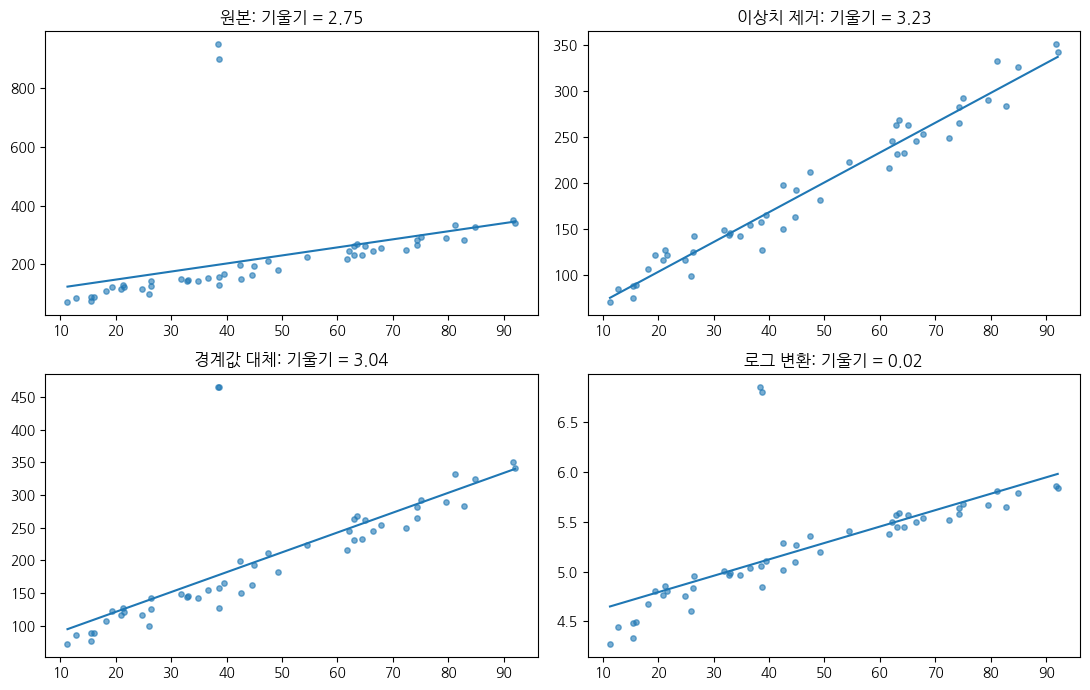

이상치 처리 방법에 따라 회귀계수가 달라질 수 있습니다.
로그 변환은 종속변수 척도를 바꾸므로 다른 기울기와 직접 비교하지 않습니다.


In [155]:
#@title 정답 확인 { display-mode: "form" }
def winsorize_upper(y):
    """IQR 상한을 넘는 값을 상한값으로 대체합니다."""
    q1, q3 = np.percentile(y, [25, 75])
    upper = q3 + 1.5 * (q3 - q1)
    return np.minimum(y, upper)


q1, q3 = np.percentile(y_sales, [25, 75])
upper = q3 + 1.5 * (q3 - q1)
keep = y_sales <= upper

strategies = {
    "원본": (x_ad, y_sales),
    "이상치 제거": (x_ad[keep], y_sales[keep]),
    "경계값 대체": (x_ad, winsorize_upper(y_sales)),
    "로그 변환": (x_ad, np.log(y_sales)),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, (name, (xs, ys)) in zip(axes.ravel(), strategies.items()):
    slope, intercept = np.polyfit(xs, ys, 1)
    x_line = np.sort(xs)

    ax.scatter(xs, ys, s=15, alpha=0.6)
    ax.plot(x_line, slope * x_line + intercept)
    ax.set_title(f"{name}: 기울기 = {slope:.2f}")

plt.tight_layout()
plt.show()

print("이상치 처리 방법에 따라 회귀계수가 달라질 수 있습니다.")
print("로그 변환은 종속변수 척도를 바꾸므로 다른 기울기와 직접 비교하지 않습니다.")


## 3. 데이터 스케일링과 분포 변환

스케일링은 변수의 단위와 범위를 맞추는 작업이다.<br> 분포 변환은 치우친 분포의 모양을 조정하는 작업으로 목적이 다르다.

| 방법 | 결과 또는 목적 | 주요 사용 상황 |
|---|---|---|
| 표준화 | 평균 0, 표준편차 1 | KNN, SVM, 신경망, K-Means, PCA |
| Min-Max 변환 | 일반적으로 0부터 1 범위 | 값의 범위를 일정하게 맞출 때 |
| 로그 및 제곱근 변환 | 오른쪽으로 치우친 분포 완화 | 금액, 횟수처럼 큰 값이 드문 변수 |
| Box-Cox 변환 | 양수 데이터에 적절한 변환 지수 탐색 | 여러 변환 후보를 비교할 때 |

의사결정나무, 랜덤 포레스트와 같은 트리 계열 모형은 변수의 크기보다 분기 기준을 사용하므로 스케일링 영향이 상대적으로 작다.<br> 학습용 데이터와 평가용 데이터를 나눌 때는 스케일러를 학습용 데이터에만 맞춰야 한다.


In [156]:
# 표준화와 Min-Max 변환을 직접 계산합니다.
x_demo = np.array([10, 30, 45, 50])

z_scaled = (x_demo - x_demo.mean()) / x_demo.std()
minmax_scaled = (
    (x_demo - x_demo.min())
    / (x_demo.max() - x_demo.min())
)

pd.DataFrame({
    "원본": x_demo,
    "Z-score": z_scaled.round(3),
    "Min-Max": minmax_scaled.round(3),
})


,원본,Z-score,Min-Max
0,10,-1.526,0.000
1,30,-0.241,0.500
2,45,0.723,0.875
3,50,1.044,1.000


### 3.1 기초 실습: Min-Max 변환 구현

Min-Max 변환은 최소값을 0, 최대값을 1로 맞춘다.

#### 수행 절차

① `minmax(x, lo, hi)` 함수를 작성한다.<br>
② C집단의 45를 변환해 0.875가 나오는지 확인한다.<br>
③ D집단의 200을 변환해 약 0.111이 나오는지 확인한다.


In [157]:
# 1) minmax 함수
import math
def minmax(x, lo, hi):
    return (x - lo) / (hi - lo)
# 2) c 집단
# 3) D 집단

print(minmax(45, 10, 50), minmax(200, 100, 1000))

0.875 0.1111111111111111


In [158]:
#@title 정답 확인 { display-mode: "form" }
def minmax(x, lo, hi):
    return (x - lo) / (hi - lo)


print(f"C집단의 45: {minmax(45, 10, 50):.3f}")
print(f"D집단의 200: {minmax(200, 100, 1000):.3f}")

# 새 값이 학습 시점의 최소값과 최대값을 벗어나면
# 변환 결과가 0부터 1 범위를 벗어날 수 있습니다.


C집단의 45: 0.875
D집단의 200: 0.111


### 3.2 응용 실습: 스케일링과 KNN 성능

KNN은 관측치 사이의 거리를 기준으로 분류한다. 한 변수의 값 범위가 지나치게 크면 그 변수가 거리 계산을 지배한다.

#### 수행 절차

① `sepal_length`의 값에 100을 곱해 단위 차이를 만든다.<br>
② 스케일링 없이 KNN 정확도를 계산한다.<br>
③ `StandardScaler`를 적용한 뒤 정확도를 다시 계산한다.<br>
④ 정확도 차이를 거리 계산의 관점에서 설명한다.


In [159]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

X = iris.drop(columns="species").copy()
X["sepal_length"] *= 100
y = iris["species"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
    stratify=y,
)

# TODO 1: 스케일링 없이 KNN 정확도 계산
knn = KNeighborsClassifier(n_neighbors=5)
print("스케일링 없이 KNN 정확도:", knn.fit(X_tr, y_tr).score(X_te, y_te))

# TODO 2: StandardScaler 적용 후 KNN 정확도 계산
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
print("스케일링 적용 후 KNN 정확도:", knn_scaled.fit(X_tr_scaled, y_tr).score(X_te_scaled, y_te))


스케일링 없이 KNN 정확도: 0.7333333333333333
스케일링 적용 후 KNN 정확도: 0.9777777777777777


In [160]:
#@title 정답 확인 { display-mode: "form" }
knn = KNeighborsClassifier(n_neighbors=5)

acc_raw = knn.fit(X_tr, y_tr).score(X_te, y_te)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

acc_scaled = knn.fit(X_tr_scaled, y_tr).score(X_te_scaled, y_te)

print(f"스케일링 없음: {acc_raw:.3f}")
print(f"표준화 적용: {acc_scaled:.3f}")

# 스케일러는 학습용 데이터에만 맞추고 평가용 데이터에는 transform만 적용합니다.


스케일링 없음: 0.733
표준화 적용: 0.978


### 3.3 심화 실습: 분포 변환 방법 비교

`titanic` 데이터의 `fare`는 오른쪽으로 치우친 분포를 보인다. 원본, 제곱근, 로그와 Box-Cox 변환을 비교한다.

Box-Cox 변환은 양수 데이터에 적용하며, 데이터에 적합한 지수 `λ`를 추정한다.

\[
y^{(\lambda)} =
\begin{cases}
\dfrac{y^\lambda-1}{\lambda}, & \lambda \neq 0 \\
\ln(y), & \lambda = 0
\end{cases}
\]

`λ`가 0에 가까우면 로그 변환과 비슷하고, 0.5에 가까우면 제곱근 변환과 비슷하다.

#### 수행 절차

① 네 가지 변환의 왜도를 표로 비교한다.  
② 변환별 히스토그램을 그린다.  
③ 왜도의 절댓값이 가장 작은 방법을 선택하는 함수를 작성한다.


왜도가 가장 작은 변환: 로그 (왜도=0.900)


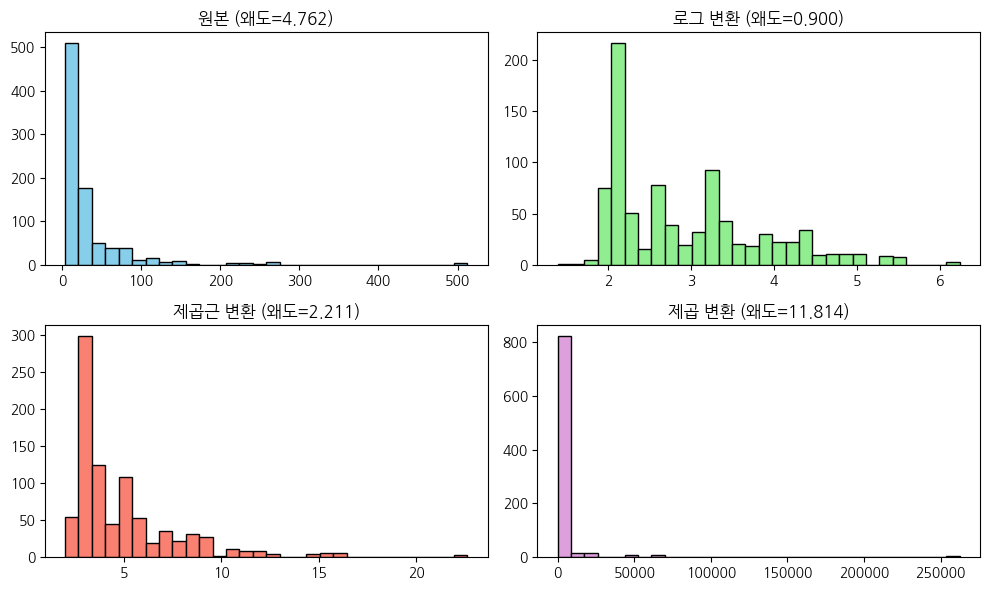

In [161]:
fare_pos = titanic.loc[titanic["fare"] > 0, "fare"].values

# TODO 1~2: 4가지 변환 왜도 비교 + 히스토그램
# TODO 3:
def best_transform(s):
    """왜도가 가장 작은 변환을 반환합니다."""
    transforms = {
        "원본": s,
        "로그": np.log(s),
        "제곱근": np.sqrt(s),
        "제곱": s**2,
    }
    skewness = {name: stats.skew(data) for name, data in transforms.items()}
    best = min(skewness, key=lambda k: abs(skewness[k]))
    return best, transforms[best], skewness[best]

best_name, best_data, best_skew = best_transform(fare_pos)
print(f"왜도가 가장 작은 변환: {best_name} (왜도={best_skew:.3f})")
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.hist(fare_pos, bins=30, color="skyblue", edgecolor="black")
plt.title("원본 (왜도={:.3f})".format(stats.skew(fare_pos)))
plt.subplot(2, 2, 2)
plt.hist(np.log(fare_pos), bins=30, color="lightgreen", edgecolor="black")
plt.title("로그 변환 (왜도={:.3f})".format(stats.skew(np.log(fare_pos))))
plt.subplot(2, 2, 3)
plt.hist(np.sqrt(fare_pos), bins=30, color="salmon", edgecolor="black")
plt.title("제곱근 변환 (왜도={:.3f})".format(stats.skew(np.sqrt(fare_pos))))
plt.subplot(2, 2, 4)
plt.hist(fare_pos**2, bins=30, color="plum", edgecolor="black")
plt.title("제곱 변환 (왜도={:.3f})".format(stats.skew(fare_pos**2)))
plt.tight_layout()
plt.show()

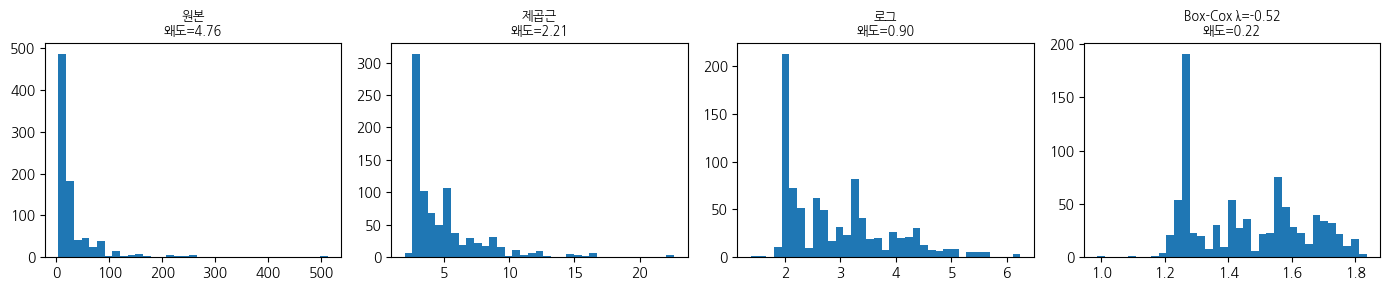

,변환,왜도
0,원본,4.762
1,제곱근,2.211
2,로그,0.900
3,Box-Cox λ=-0.52,0.217


변환별 왜도 절댓값:
{'원본': np.float64(4.762), '제곱근': np.float64(2.211), '로그': np.float64(0.9), 'Box-Cox': np.float64(0.217)}
선택: Box-Cox


('Box-Cox',
 array([1.23263859, 1.7045828 , 1.26344677, 1.67052616, 1.26871586,
        1.28509254, 1.66756504, 1.52217664, 1.36871199, 1.58785998,
        1.47206202, 1.5662284 , 1.26871586, 1.59439322, 1.26040581,
        1.46215514, 1.5824424 , 1.41083377, 1.48887933, 1.23141395,
        1.56245145, 1.41083377, 1.26784776, 1.6145835 , 1.52217664,
        1.59498399, 1.23141395, 1.80571576, 1.26148435, 1.26219762,
        1.57388499, 1.76877021, 1.2558535 , 1.35188577, 1.71923307,
        1.66789935, 1.23162014, 1.26871586, 1.48887933, 1.37144639,
        1.32109802, 1.52145397, 1.26219762, 1.63796149, 1.26148435,
        1.26871586, 1.45466491, 1.2558535 , 1.52785885, 1.48641439,
        1.63127475, 1.25804947, 1.71230702, 1.56245145, 1.68906186,
        1.6145835 , 1.35188577, 1.23162014, 1.57406963, 1.65451619,
        1.23162014, 1.71655626, 1.72079003, 1.57501349, 1.57388499,
        1.45071408, 1.35188577, 1.27318121, 1.26344677, 1.29283824,
        1.35188577, 1.65451619, 1.70

In [162]:
#@title 정답 확인 { display-mode: "form" }
fare_boxcox, lambda_value = stats.boxcox(fare_pos)

transforms = {
    "원본": fare_pos,
    "제곱근": np.sqrt(fare_pos),
    "로그": np.log(fare_pos),
    f"Box-Cox λ={lambda_value:.2f}": fare_boxcox,
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
rows = []

for ax, (name, values) in zip(axes, transforms.items()):
    skewness = stats.skew(values)
    rows.append({"변환": name, "왜도": round(skewness, 3)})

    ax.hist(values, bins=35)
    ax.set_title(f"{name}\n왜도={skewness:.2f}", fontsize=9)

plt.tight_layout()
plt.show()

display(pd.DataFrame(rows))


def best_transform(values):
    """양수 데이터에서 왜도 절댓값이 가장 작은 변환을 선택합니다."""
    values = np.asarray(values, dtype=float)

    candidates = {
        "원본": values,
        "제곱근": np.sqrt(values),
        "로그": np.log(values),
        "Box-Cox": stats.boxcox(values)[0],
    }

    scores = {
        name: abs(stats.skew(result))
        for name, result in candidates.items()
    }

    best_name = min(scores, key=scores.get)

    print("변환별 왜도 절댓값:")
    print({name: round(score, 3) for name, score in scores.items()})
    print("선택:", best_name)

    return best_name, candidates[best_name]


best_transform(fare_pos)


## 4. 범주형 변수 인코딩

통계모형과 대부분의 머신러닝 모형은 숫자 입력을 사용한다.<br> 범주형 변수는 범주의 의미에 맞게 수치화해야 한다.

| 방법 | 적용 대상 | 예시 |
|---|---|---|
| One-Hot Encoding | 범주 사이에 순서가 없을 때 | 성별, 직업군, 지역 |
| 순서형 인코딩 | 범주 사이에 명확한 순서가 있을 때 | 학점, 등급, 만족도 |

회귀분석에 절편을 포함하면서 범주 `k`개를 모두 더미변수로 만들면 완전한 선형종속이 생긴다.<br> 일반적으로 기준 범주 하나를 제외한 `k-1`개만 사용한다.


In [163]:
# One-Hot Encoding 예시
customers = pd.DataFrame({
    "고객": [1, 2, 3, 4],
    "성별": ["여성", "여성", "남성", "남성"],
    "직업군": ["A", "C", "B", "A"],
})

display(customers)

encoded_customers = pd.get_dummies(
    customers,
    columns=["성별", "직업군"],
    dtype=int,
)

display(encoded_customers)


,고객,성별,직업군
0,1,여성,A
1,2,여성,C
2,3,남성,B
3,4,남성,A


,고객,성별_남성,성별_여성,직업군_A,직업군_B,직업군_C
0,1,0,1,1,0,0
1,2,0,1,0,0,1
2,3,1,0,0,1,0
3,4,1,0,1,0,0


### 4.1 기초 실습: 순서형 범주 수치화

학점과 등급은 범주 사이에 순서가 있다. `map()`을 사용해 각 범주를 의미 있는 순서로 변환한다.

#### 수행 절차

① 학점 A, B, C를 각각 1, 2, 3으로 변환한다.<br>
② 1등급, 2등급, 3등급을 각각 1, 2, 3으로 변환한다.<br>
③ 변환 결과를 새 열에 저장한다.


In [164]:
grade = pd.DataFrame({"고객": [1, 2, 3, 4],
                      "학점": ["A", "C", "B", "A"],
                      "등급": ["2등급", "3등급", "1등급", "1등급"]})

# TODO: 학점_Label, 등급_Label 컬럼 추가
grade["학점_Label"] = grade["학점"].map({"A": 4, "B": 3, "C": 2, "D": 1})
grade["등급_Label"] = grade["등급"].map({"1등급": 1, "2등급": 2, "3등급": 3, "4등급": 4})

grade

,고객,학점,등급,학점_Label,등급_Label
0,1,A,2등급,4,2
1,2,C,3등급,2,3
2,3,B,1등급,3,1
3,4,A,1등급,4,1


In [165]:
#@title 정답 확인 { display-mode: "form" }
grade["학점_순서"] = grade["학점"].map({
    "A": 1,
    "B": 2,
    "C": 3,
})

grade["등급_순서"] = grade["등급"].map({
    "1등급": 1,
    "2등급": 2,
    "3등급": 3,
})

display(grade)

# 순서가 없는 범주에 임의의 정수를 부여하면
# 모형이 존재하지 않는 크기 관계를 학습할 수 있습니다.


,고객,학점,등급,학점_Label,등급_Label,학점_순서,등급_순서
0,1,A,2등급,4,2,1,2
1,2,C,3등급,2,3,3,3
2,3,B,1등급,3,1,2,1
3,4,A,1등급,4,1,1,1


### 4.2 응용 실습: One-Hot Encoding 적용

`tips` 데이터의 `sex`, `smoker`, `day`, `time`은 순서가 없는 범주형 변수이다. 회귀분석 입력을 만들기 위해 One-Hot Encoding을 적용한다.

#### 수행 절차

① `pd.get_dummies()`를 사용한다.<br>
② `drop_first=True`로 기준 범주 하나를 제외한다.<br>
③ 원본과 변환 후의 열 개수를 비교한다.<br>
④ 각 변수에서 범주 수보다 더미변수 수가 하나 적은 이유를 확인한다.


In [166]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [167]:
for col in tips.select_dtypes(include="object").columns:
    print(f"{col}: {tips[col].unique()}")

In [168]:
# TODO: 인코딩 + 컬럼 변화 분석

# 1,2 
category_encoded = pd.get_dummies(tips, columns=["sex", "smoker", "day", "time"], drop_first=True)
category_encoded.head()

,total_bill,tip,size,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,1.01,2,True,True,False,False,True,True
1,10.34,1.66,3,False,True,False,False,True,True
2,21.01,3.50,3,False,True,False,False,True,True
3,23.68,3.31,2,False,True,False,False,True,True
4,24.59,3.61,4,True,True,False,False,True,True


In [194]:
# 3 원본과 변환 후의 열 개수 비교 

print("원본 열 개수:", tips.shape[1])
print("변환 후 열 개수:", category_encoded.shape[1])

# 4 더미 변수 적은 이유
# 다중공선성 방지하기 위해서 (카테고리 변수중 하나를 할면 두 번째 변수는 완벽히 알 수 있음)
# 선형 회귀, 로지스틱 회귀 모형 만들려고 하면 변수 줄이는 거임

for column in ["sex", "smoker", "day", "time"]:
    print(f"{column} 원래 개수: {tips[column].unique()}")
    print(f"{column} 변환 더미 변수 개수: {len([col for col in category_encoded.columns if col.startswith(column)])}")

원본 열 개수: 7
변환 후 열 개수: 9
sex 원래 개수: ['Female', 'Male']
Categories (2, object): ['Male', 'Female']
sex 변환 더미 변수 개수: 1
smoker 원래 개수: ['No', 'Yes']
Categories (2, object): ['Yes', 'No']
smoker 변환 더미 변수 개수: 1
day 원래 개수: ['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']
day 변환 더미 변수 개수: 3
time 원래 개수: ['Dinner', 'Lunch']
Categories (2, object): ['Lunch', 'Dinner']
time 변환 더미 변수 개수: 1


In [170]:
#@title 정답 확인 { display-mode: "form" }
categorical_columns = ["sex", "smoker", "day", "time"]

encoded = pd.get_dummies(
    tips,
    columns=categorical_columns,
    drop_first=True,
    dtype=int,
)

print("원본 열 수:", tips.shape[1])
print("변환 후 열 수:", encoded.shape[1])

for column in categorical_columns:
    category_count = tips[column].nunique()
    dummy_columns = [
        name
        for name in encoded.columns
        if name.startswith(column + "_")
    ]

    print(
        f"{column}: 범주 {category_count}개, "
        f"더미변수 {len(dummy_columns)}개"
    )

display(encoded.head(3))


원본 열 수: 7
변환 후 열 수: 9
sex: 범주 2개, 더미변수 1개
smoker: 범주 2개, 더미변수 1개
day: 범주 4개, 더미변수 3개
time: 범주 2개, 더미변수 1개


,total_bill,tip,size,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,1.01,2,1,1,0,0,1,1
1,10.34,1.66,3,0,1,0,0,1,1
2,21.01,3.50,3,0,1,0,0,1,1


### 4.3 심화 실습: 더미변수 함정 확인

성별의 모든 더미변수와 절편을 함께 사용하면 다음 관계가 성립한다.

`성별_여성 + 성별_남성 = 1 = 절편`

따라서 설명변수 사이에 완전한 선형종속이 생기며 회귀계수를 안정적으로 추정하기 어렵다.

#### 수행 절차

① 성별 더미변수 두 개와 절편을 모두 포함해 회귀모형을 적합한다.<br>
② `drop_first=True`로 더미변수 하나만 사용한 모형을 적합한다.<br>
③ 두 모형의 조건수와 경고 메시지를 비교한다.


In [196]:
# 성별 더미변수 두 개와 절편을 모두 포함해 회귀모형을 적합한다.



In [198]:
# TODO 1: 전체 dummy 포함 OLS -> summary 확인
# ------------------------------------------------------------------
# sex 변수 전체를 더미화 (drop_first=False)
X_all_dummies = pd.get_dummies(tips[['sex']], drop_first=False, dtype=float)
# 절편(Intercept) 항 추가
X_all_dummies = sm.add_constant(X_all_dummies)
y = tips['tip']

# OLS 회귀모형 적합
model_all = sm.OLS(y, X_all_dummies).fit()
print("=== [TODO 1] 전체 더미 포함 모델 Summary ===")
print(model_all.summary())


=== [TODO 1] 전체 더미 포함 모델 Summary ===
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.926
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.166
Time:                        02:40:07   Log-Likelihood:                -423.98
No. Observations:                 244   AIC:                             852.0
Df Residuals:                     242   BIC:                             859.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

## 다중공선성 발생함

In [199]:
# TODO 2: drop_first 버전과 Cond. No. 비교

X_drop_first = pd.get_dummies(tips[['sex']], drop_first=True, dtype=float)
X_drop_first = sm.add_constant(X_drop_first)
model_drop_first = sm.OLS(y, X_drop_first).fit()
print("\n=== [TODO 2] drop_first 모델 Summary ===")
print(model_drop_first.summary())


=== [TODO 2] drop_first 모델 Summary ===
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.926
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.166
Time:                        02:41:05   Log-Likelihood:                -423.98
No. Observations:                 244   AIC:                             852.0
Df Residuals:                     242   BIC:                             859.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

### <br> 첫행을 버리니 조건 수가 줄어들어 안정적임

In [172]:
#@title 정답 확인 { display-mode: "form" }
# 모든 성별 더미변수와 절편을 함께 사용한 모형
X_trap = pd.get_dummies(
    tips[["total_bill", "sex"]],
    columns=["sex"],
    drop_first=False,
    dtype=float,
)
X_trap = sm.add_constant(X_trap)
model_trap = sm.OLS(tips["tip"], X_trap).fit()

# 기준 범주 하나를 제외한 모형
X_ok = pd.get_dummies(
    tips[["total_bill", "sex"]],
    columns=["sex"],
    drop_first=True,
    dtype=float,
)
X_ok = sm.add_constant(X_ok)
model_ok = sm.OLS(tips["tip"], X_ok).fit()

print(
    "전체 더미변수 사용:",
    f"행렬 순위 {np.linalg.matrix_rank(X_trap)} / 열 {X_trap.shape[1]}",
)
print(
    "기준 범주 제외:",
    f"행렬 순위 {np.linalg.matrix_rank(X_ok)} / 열 {X_ok.shape[1]}",
)
print(f"전체 더미변수 조건수: {model_trap.condition_number:,.1f}")
print(f"기준 범주 제외 조건수: {model_ok.condition_number:,.1f}")

print("\n전체 더미변수 모형의 summary 하단 경고:")
display(model_trap.summary().tables[2])

# 행렬 순위가 열 개수보다 작으면 설명변수 사이에 완전한 선형종속이 있습니다.
# 조건수는 변수 스케일의 영향도 받으므로 행렬 순위와 함께 해석합니다.


전체 더미변수 사용: 행렬 순위 3 / 열 4
기준 범주 제외: 행렬 순위 3 / 열 3
전체 더미변수 조건수: 121,019,719,470,755,120.0
기준 범주 제외 조건수: 63.0

전체 더미변수 모형의 summary 하단 경고:


Omnibus:,20.499,Durbin-Watson:,2.149
Prob(Omnibus):,0.000,Jarque-Bera (JB):,38.652
Skew:,0.447,Prob(JB):,4.05e-09
Kurtosis:,4.733,Cond. No.,1.21e+17


## 5. 상관분석

상관계수는 두 변수의 관계 방향과 강도를 요약한 값이다. Pearson 상관계수는 선형 관계를 측정하며 범위는 -1부터 1이다.

| 값의 특징 | 해석 |
|---|---|
| 부호가 양수 | 한 변수가 증가할 때 다른 변수도 증가하는 경향 |
| 부호가 음수 | 한 변수가 증가할 때 다른 변수는 감소하는 경향 |
| 절댓값이 1에 가까움 | 선형 관계가 강함 |
| 0에 가까움 | 선형 관계가 약함 |

강도 기준은 분야와 표본 크기에 따라 달라지므로 고정된 규칙으로 사용하지 않는다. 상관계수만 보지 말고 산점도와 이상치를 함께 확인한다.

### 해석 시 주의사항

① 비선형 관계는 Pearson 상관계수에 잘 나타나지 않을 수 있다.<br>
② 이상치 한두 건이 상관계수를 크게 바꿀 수 있다.<br>
③ 제3의 변수가 두 변수 모두에 영향을 줄 수 있다.<br>
④ 상관관계만으로 인과관계를 판단할 수 없다.


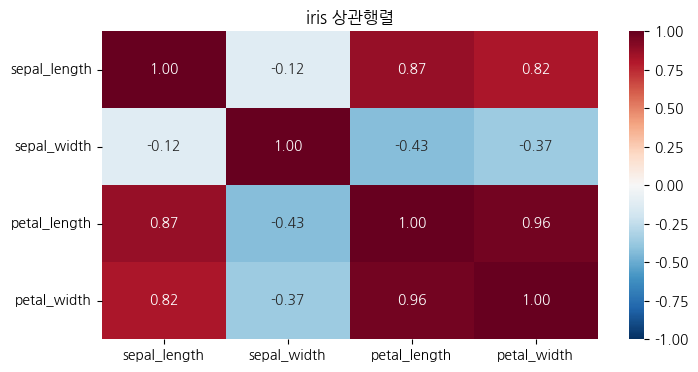

In [173]:
# iris 수치형 변수의 상관행렬을 확인합니다.
iris_numeric = iris.drop(columns="species")
iris_corr = iris_numeric.corr()

sns.heatmap(
    iris_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

plt.title("iris 상관행렬")
plt.show()


### 5.1 기초 실습: 상관계수 계산과 해석

`tips` 데이터에서 `total_bill`과 `tip`의 Pearson 상관계수를 계산하고 산점도를 그린다.

#### 수행 절차

① `corr()`로 상관계수를 계산한다.<br>
② 산점도로 관계의 방향과 형태를 확인한다.<br>
③ 계산값과 그래프를 근거로 한 문장으로 해석한다.<br>
④ 상관관계가 인과관계를 뜻하지 않는 이유를 함께 적는다.


In [ ]:
# 1.상관계수
tips_numeric = tips.select_dtypes(include=np.number)
corr_matrix = tips_numeric.corr()
corr_matrix

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


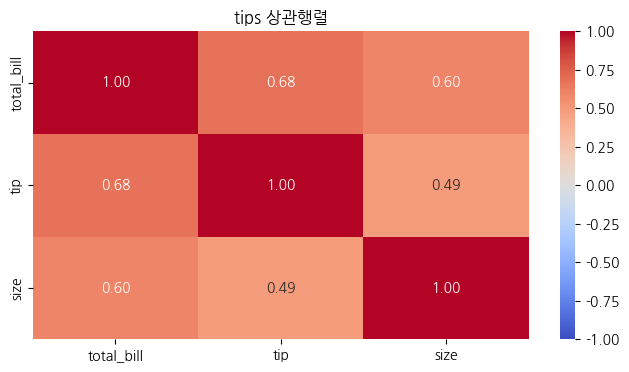

In [207]:
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.title("tips 상관행렬")
plt.show()

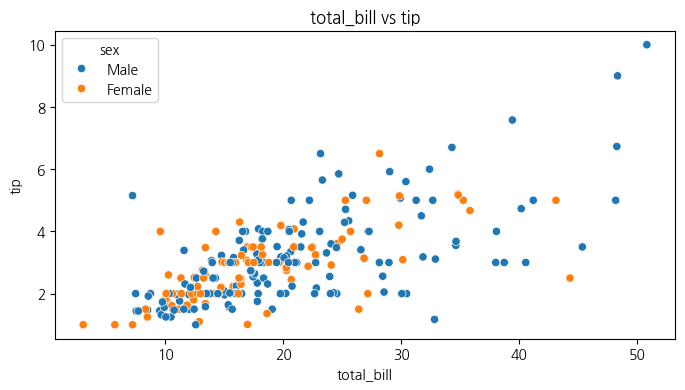

상관계수 R: 0.676


In [ ]:
# 2. 산점도 시각화
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex")
plt.title("total_bill vs tip")
plt.show()

R = tips["total_bill"].corr(tips["tip"])
print(f"상관계수 R: {R:.3f}")

## 작은 양의 상관관계를 보인다

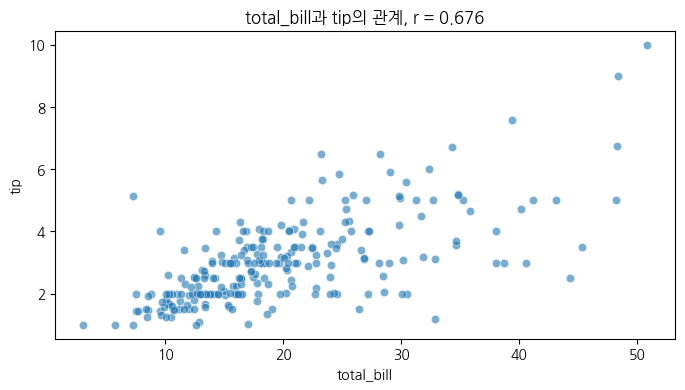

Pearson 상관계수: 0.676
식사 금액이 클수록 팁도 커지는 양의 선형 경향이 나타납니다.
다만 상관계수만으로 인과관계를 판단할 수 없습니다.


In [175]:
#@title 정답 확인 { display-mode: "form" }
r = tips["total_bill"].corr(tips["tip"])

sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    alpha=0.6,
)

plt.title(f"total_bill과 tip의 관계, r = {r:.3f}")
plt.show()

print(f"Pearson 상관계수: {r:.3f}")
print("식사 금액이 클수록 팁도 커지는 양의 선형 경향이 나타납니다.")
print("다만 상관계수만으로 인과관계를 판단할 수 없습니다.")


### 5.2 응용 실습: 이상치가 상관계수에 미치는 영향

키와 몸무게 데이터에서 첫 번째 관측치 `(175, 52)`는 전체 흐름에서 벗어나 있다.

#### 수행 절차

① 전체 8명의 상관계수를 계산한다.<br>
② 첫 번째 관측치를 제외한 뒤 상관계수를 다시 계산한다.<br>
③ 산점도에서 이상치를 구분해 표시한다.<br>
④ 제거 전후의 상관계수 차이를 설명한다.


1) 이상치 포함 전체 상관계수 (r): 0.3867
2) 이상치 제거 후 상관계수   (r): 0.8674
3) 상관계수 변화량            : 0.4807


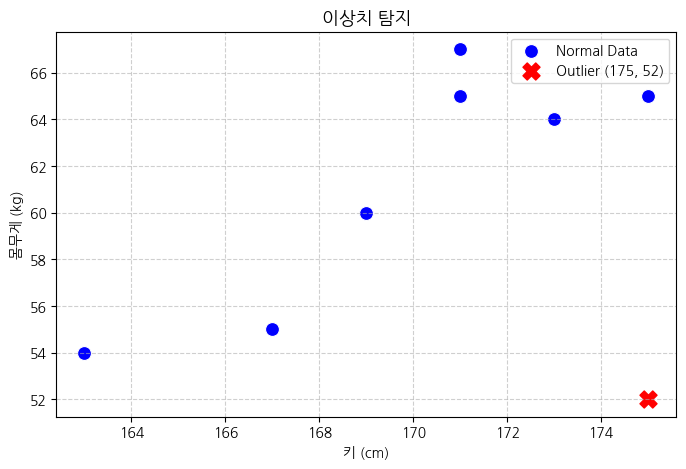

In [212]:
prof = pd.DataFrame({
    "H_cm": [175, 173, 163, 175, 171, 169, 167, 171],
    "W_kg": [ 52,  64,  54,  65,  67,  60,  55,  65],
})

# TODO: r 전/후 비교 + 시각화

# 1. 전체 8명의 상관계수 계산
r_all = prof["H_cm"].corr(prof["W_kg"])

# 2. 첫 번째 관측치(인덱스 0)를 제외한 뒤 상관계수 재계산
prof_no_outlier = prof.iloc[1:].copy()
r_no_outlier = prof_no_outlier["H_cm"].corr(prof_no_outlier["W_kg"])

print(f"1) 이상치 포함 전체 상관계수 (r): {r_all:.4f}")
print(f"2) 이상치 제거 후 상관계수   (r): {r_no_outlier:.4f}")
print(f"3) 상관계수 변화량            : {r_no_outlier - r_all:.4f}")

# 3. 산점도에서 이상치를 구분해 표시
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=prof_no_outlier, x="H_cm", y="W_kg", 
    color="blue", s=100, label="Normal Data"
)

# 이상치 포인트 (첫 번째 행: 175, 52)
plt.scatter(
    prof.loc[0, "H_cm"], prof.loc[0, "W_kg"], 
    color="red", s=150, marker="X", label="Outlier (175, 52)"
)

plt.title("이상치 탐지", fontsize=13)
plt.xlabel("키 (cm)")
plt.ylabel("몸무게 (kg)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

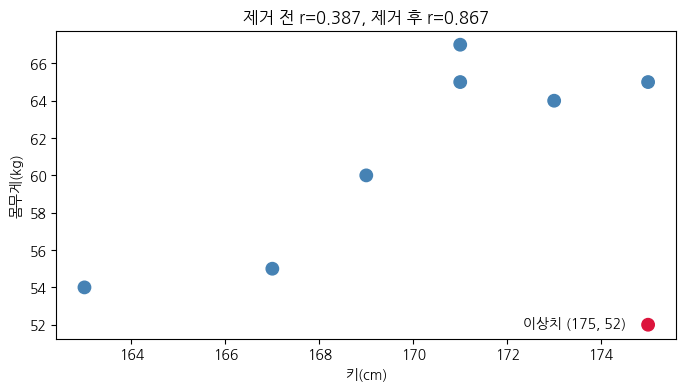

이상치 한 건만 제거해도 상관계수가 크게 달라집니다.


In [177]:
#@title 정답 확인 { display-mode: "form" }
r_before = prof["H_cm"].corr(prof["W_kg"])

prof_without_outlier = prof.drop(index=0)
r_after = prof_without_outlier["H_cm"].corr(
    prof_without_outlier["W_kg"]
)

colors = ["crimson"] + ["steelblue"] * 7

plt.scatter(
    prof["H_cm"],
    prof["W_kg"],
    c=colors,
    s=80,
)
plt.annotate(
    "이상치 (175, 52)",
    (175, 52),
    textcoords="offset points",
    xytext=(-90, -2),
)
plt.xlabel("키(cm)")
plt.ylabel("몸무게(kg)")
plt.title(f"제거 전 r={r_before:.3f}, 제거 후 r={r_after:.3f}")
plt.show()

print("이상치 한 건만 제거해도 상관계수가 크게 달라집니다.")


### 5.3 심화 실습: Pearson, Spearman과 편상관

상관계수의 한계를 세 가지 사례로 확인한다.

#### A. 비선형 관계

`y = x² + 잡음` 데이터를 만든다.<br> Pearson 상관계수가 0에 가까워도 산점도에는 뚜렷한 U자 관계가 나타나는지 확인한다.

#### B. 단조 비선형 관계

`y = exp(x) + 잡음` 데이터에서 Pearson과 Spearman 상관계수를 비교한다.<br> Spearman 상관계수는 실제 값보다 순위를 사용하므로 단조 증가 관계를 잘 포착한다.

#### C. 교란변수를 통제한 편상관

나이가 뱃살과 연봉 모두에 영향을 주는 데이터를 만든다.<br> 단순상관을 계산한 뒤 나이로 설명되는 부분을 제거한 잔차끼리 상관계수를 계산한다.


=== [A] 비선형 관계 (U자형) ===
Pearson r: 0.0022 (0에 가까워 선형 관계는 없으나 U자형 패턴 존재)


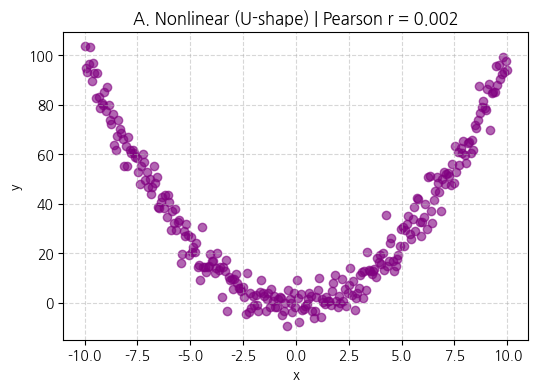


=== [B] 단조 비선형 관계 (지수함수) ===
Pearson r  : 0.9311 (선형 직선 형태와의 유사도)
Spearman r : 0.9812 (순위 기반, 단조 증가 관계를 완벽히 포착)

=== [C] 교란변수(나이)를 통제한 편상관 ===
단순 상관계수 (x, y)      : 0.6791 (착시 현상으로 인해 높게 나타남)
편상관 계수   (res_x, res_y): 0.0810 (나이 영향을 제거하면 실제 관계는 0에 가까움)


In [213]:
n = 300
# TODO (A): y = x² 데이터 -> Pearson r 확인 + 산점도
# ------------------------------------------------------------------
# x는 -10부터 10까지 대칭적인 분포 생성
x_a = np.linspace(-10, 10, n)
y_a = x_a**2 + np.random.normal(0, 5, n)

r_a, _ = pearsonr(x_a, y_a)
print(f"=== [A] 비선형 관계 (U자형) ===")
print(f"Pearson r: {r_a:.4f} (0에 가까워 선형 관계는 없으나 U자형 패턴 존재)")

plt.figure(figsize=(6, 4))
plt.scatter(x_a, y_a, alpha=0.6, color='purple')
plt.title(f"A. Nonlinear (U-shape) | Pearson r = {r_a:.3f}")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ------------------------------------------------------------------
# TODO (B): y = exp(x) 데이터 -> pearsonr vs spearmanr
# ------------------------------------------------------------------
x_b = np.linspace(0, 3, n)
y_b = np.exp(x_b) + np.random.normal(0, 0.5, n)

r_b_pearson, _ = pearsonr(x_b, y_b)
r_b_spearman, _ = spearmanr(x_b, y_b)

print(f"\n=== [B] 단조 비선형 관계 (지수함수) ===")
print(f"Pearson r  : {r_b_pearson:.4f} (선형 직선 형태와의 유사도)")
print(f"Spearman r : {r_b_spearman:.4f} (순위 기반, 단조 증가 관계를 완벽히 포착)")

# ------------------------------------------------------------------
# TODO (C): z(나이) -> x(뱃살), y(연봉) 생성 -> 단순상관 vs 잔차 기반 편상관
# ------------------------------------------------------------------
# 공통 원인 z (나이: 20세~60세)
z_age = np.random.uniform(20, 60, n)

# 나이(z)가 증가함에 따라 뱃살(x)과 연봉(y)이 모두 증가하도록 데이터 생성
x_fat = 0.5 * z_age + np.random.normal(0, 5, n)
y_income = 100 * z_age + np.random.normal(0, 500, n)

# 1) 단순 상관계수 (나이의 영향을 통제하지 않음)
r_xy_simple, _ = pearsonr(x_fat, y_income)

# 2) 잔차 기반 편상관 (나이 z의 영향을 회귀로 제거한 잔차끼리의 상관계수)
# x = a*z + b 의 잔차 (나이로 설명되지 않는 뱃살)
res_x = sm.OLS(x_fat, sm.add_constant(z_age)).fit().resid

# y = c*z + d 의 잔차 (나이로 설명되지 않는 연봉)
res_y = sm.OLS(y_income, sm.add_constant(z_age)).fit().resid

r_xy_partial, _ = pearsonr(res_x, res_y)

print(f"\n=== [C] 교란변수(나이)를 통제한 편상관 ===")
print(f"단순 상관계수 (x, y)      : {r_xy_simple:.4f} (착시 현상으로 인해 높게 나타남)")
print(f"편상관 계수   (res_x, res_y): {r_xy_partial:.4f} (나이 영향을 제거하면 실제 관계는 0에 가까움)")

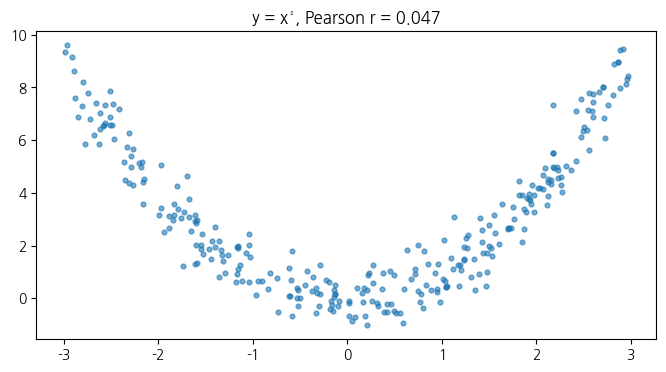

지수 관계
Pearson: 0.822
Spearman: 0.965

뱃살과 연봉의 단순상관: 0.851
나이를 통제한 편상관: 0.06


In [179]:
#@title 정답 확인 { display-mode: "form" }
from scipy.stats import pearsonr, spearmanr

n = 300

# A. U자 형태의 비선형 관계
x = np.random.uniform(-3, 3, n)
y_square = x ** 2 + np.random.normal(0, 0.7, n)

r_square = pearsonr(x, y_square)[0]

plt.scatter(x, y_square, s=12, alpha=0.6)
plt.title(f"y = x², Pearson r = {r_square:.3f}")
plt.show()

# B. 단조 증가하는 비선형 관계
y_exp = np.exp(x) + np.random.normal(0, 0.3, n)

pearson_exp = pearsonr(x, y_exp)[0]
spearman_exp = spearmanr(x, y_exp)[0]

print("지수 관계")
print(f"Pearson: {pearson_exp:.3f}")
print(f"Spearman: {spearman_exp:.3f}")

# C. 나이를 통제한 편상관
age = np.random.uniform(25, 60, n)
belly = 0.6 * age + np.random.normal(0, 3, n)
salary = 100 * age + np.random.normal(0, 400, n)

r_simple = pearsonr(belly, salary)[0]

belly_pred = np.poly1d(np.polyfit(age, belly, 1))(age)
salary_pred = np.poly1d(np.polyfit(age, salary, 1))(age)

belly_residual = belly - belly_pred
salary_residual = salary - salary_pred

r_partial = pearsonr(belly_residual, salary_residual)[0]

print("\n뱃살과 연봉의 단순상관:", round(r_simple, 3))
print("나이를 통제한 편상관:", round(r_partial, 3))


## 6. 회귀분석

회귀분석은 독립변수 `X`와 종속변수 `Y`의 관계를 수식으로 나타내고 값을 설명하거나 예측하는 방법이다.

\[
Y = f(X) + \varepsilon
\]

잔차는 실제값에서 예측값을 뺀 값이다. 최소제곱법은 잔차 제곱합이 가장 작아지는 회귀식을 찾는다.

### 결과 확인 순서

① `Prob(F-statistic)`으로 회귀모형 전체가 유의한지 확인한다.  
② 각 회귀계수의 `P>|t|`로 개별 변수가 유의한지 확인한다.  
③ 조정된 결정계수로 설명력을 확인한다.  
④ 회귀계수의 부호와 크기를 업무 단위로 해석한다.

R²는 설명력을 나타낸다. MAE, MSE와 RMSE는 예측 오차를 나타내며 값이 작을수록 좋다.


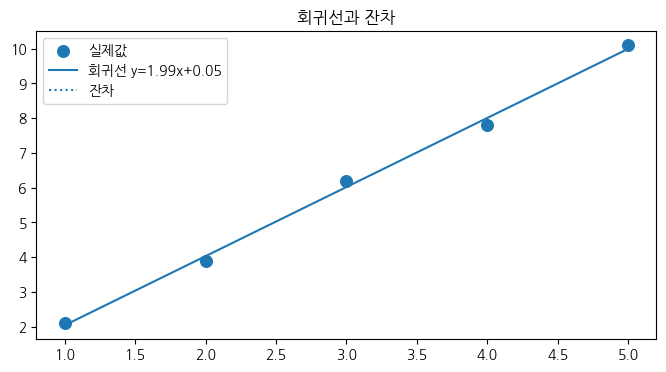

In [180]:
# 잔차는 실제값에서 예측값을 뺀 값입니다.
x_demo = np.array([1, 2, 3, 4, 5])
y_demo = np.array([2.1, 3.9, 6.2, 7.8, 10.1])

slope, intercept = np.polyfit(x_demo, y_demo, 1)
prediction = slope * x_demo + intercept

plt.scatter(x_demo, y_demo, s=70, zorder=3, label="실제값")
plt.plot(
    x_demo,
    prediction,
    label=f"회귀선 y={slope:.2f}x+{intercept:.2f}",
)
plt.vlines(
    x_demo,
    prediction,
    y_demo,
    linestyles=":",
    label="잔차",
)
plt.title("회귀선과 잔차")
plt.legend()
plt.show()


### 6.1 기초 실습: 최소제곱법 계산

관측치 A(1, 1), B(2, 2), C(3, 3)에 대해 세 후보 직선의 잔차 제곱합을 계산한다.

| 후보 | 회귀식 |
|---|---|
| ① | `y = 2x` |
| ② | `y = x + 2` |
| ③ | `y = x` |

잔차 제곱합이 가장 작은 직선을 선택하고 `np.polyfit()` 결과와 비교한다.


In [181]:
obs_x = np.array([1, 2, 3]); obs_y = np.array([1, 2, 3])
lines = {"① y=2x": lambda x: 2*x, "② y=x+2": lambda x: x + 2, "③ y=x": lambda x: x}

# TODO: 각 직선의 ∑잔차² 계산 → 최소 찾기

In [182]:
#@title 정답 확인 { display-mode: "form" }
sse_results = {}

for name, function in lines.items():
    prediction = function(obs_x)
    sse = ((obs_y - prediction) ** 2).sum()
    sse_results[name] = sse
    print(f"{name}: 잔차 제곱합 = {sse}")

best_line = min(sse_results, key=sse_results.get)
print("\n가장 작은 잔차 제곱합:", best_line)

slope, intercept = np.polyfit(obs_x, obs_y, 1)
print(f"np.polyfit 결과: y={slope:.2f}x+{intercept:.2f}")


① y=2x: 잔차 제곱합 = 14
② y=x+2: 잔차 제곱합 = 12
③ y=x: 잔차 제곱합 = 0

가장 작은 잔차 제곱합: ③ y=x
np.polyfit 결과: y=1.00x+0.00


### 6.2 응용 실습: 다중회귀 결과 해석

상품 A의 쿠폰 배포 매수와 판매가격이 구매고객수에 미치는 영향을 분석한다.

#### 수행 절차

① `구매고객수 ~ 쿠폰배포매수 + 판매가격` 모형을 적합한다.<br>
② 조정된 R²와 F 검정 결과를 확인한다.<br>
③ 각 회귀계수의 P값을 확인해 유의하지 않은 변수를 찾는다.<br>
④ 해당 변수를 제외하고 모형을 다시 적합한다.<br>
⑤ 쿠폰 3,000장을 배포했을 때 예상 구매고객수를 계산한다.


In [183]:
np.random.seed(7)
n = 15

coupon = np.random.uniform(500, 3000, n).round()
price = np.random.uniform(1500, 2500, n).round()

buyers = (
    0.109 * coupon
    + 0.003 * price
    + 274
    + np.random.normal(0, 28, n)
).round()

df_mkt = pd.DataFrame({
    "쿠폰배포매수": coupon,
    "판매가격": price,
    "구매고객수": buyers,
})

# TODO 1: 다중회귀 모형 적합
# TODO 2: F 검정, 계수 P값과 조정된 R² 확인
# TODO 3: 유의하지 않은 변수 제거 후 재적합 및 예측


In [184]:
#@title 정답 확인 { display-mode: "form" }
# 1. 다중회귀 모형
X_multi = sm.add_constant(
    df_mkt[["쿠폰배포매수", "판매가격"]]
)
model_multi = sm.OLS(
    df_mkt["구매고객수"],
    X_multi,
).fit()

print(model_multi.summary())

# 2. 결과 확인
print("\n모형 전체")
print(f"조정된 R²: {model_multi.rsquared_adj:.3f}")
print(f"F 검정 P값: {model_multi.f_pvalue:.4g}")

print("\n회귀계수별 P값")
for name, p_value in model_multi.pvalues.items():
    result = "유의" if p_value < 0.05 else "유의하지 않음"
    print(f"{name}: {p_value:.4f}, {result}")

# 3. 판매가격을 제외한 단순회귀 모형
X_simple = sm.add_constant(
    df_mkt[["쿠폰배포매수"]]
)
model_simple = sm.OLS(
    df_mkt["구매고객수"],
    X_simple,
).fit()

intercept, coupon_coef = model_simple.params
predicted_buyers = intercept + coupon_coef * 3000

print("\n최종 회귀식")
print(
    f"구매고객수 = {intercept:.1f} "
    f"+ {coupon_coef:.3f} × 쿠폰배포매수"
)
print(f"쿠폰 3,000장 배포 시 예상 고객수: {predicted_buyers:.0f}명")


                            OLS Regression Results                            
Dep. Variable:                  구매고객수   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     24.70
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           5.57e-05
Time:                        02:35:38   Log-Likelihood:                -72.512
No. Observations:                  15   AIC:                             151.0
Df Residuals:                      12   BIC:                             153.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        376.3079     76.121      4.944      0.0

### 6.3 심화 실습: 경사하강법으로 회귀계수 찾기

경사하강법은 손실함수가 감소하는 방향으로 회귀계수를 반복해서 갱신하는 최적화 방법이다. 선형회귀에서는 최소제곱 해와 비슷한 결과에 수렴한다.

\[
L(a,b)=\frac{1}{n}\sum_{i=1}^{n}\left(y_i-(ax_i+b)\right)^2
\]

\[
\frac{\partial L}{\partial a}
=-\frac{2}{n}\sum_{i=1}^{n}x_i(y_i-\hat y_i),
\qquad
\frac{\partial L}{\partial b}
=-\frac{2}{n}\sum_{i=1}^{n}(y_i-\hat y_i)
\]

#### 수행 절차

① `a=0`, `b=0`에서 시작한다.  
② 학습률 0.01로 1,000회 갱신한다.  
③ 100회마다 MSE를 기록해 손실 곡선을 그린다.  
④ 최종 계수를 `np.polyfit()` 결과와 비교한다.


In [185]:
x_gd = np.random.uniform(0, 10, 100)
y_gd = 3*x_gd + 5 + np.random.normal(0, 2, 100)

# TODO: 경사하강법 구현 (a, b, 학습률 lr=0.01, epochs=1000)

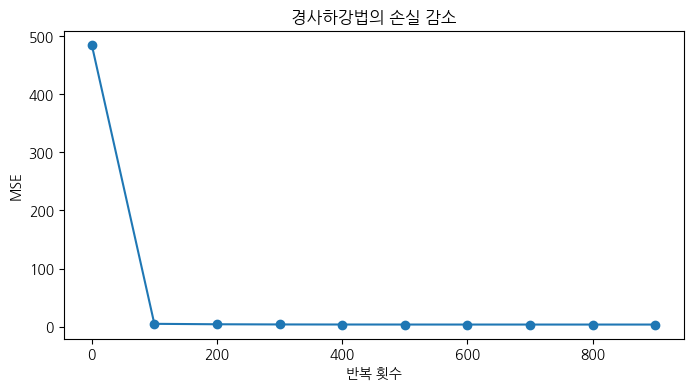

경사하강법: a=3.1120, b=4.1789
np.polyfit: a=3.1072, b=4.2107


In [186]:
#@title 정답 확인 { display-mode: "form" }
x = x_gd
y = y_gd

a = 0.0
b = 0.0
learning_rate = 0.01
epochs = 1000
n = len(x)

loss_history = []

for epoch in range(epochs):
    y_hat = a * x + b
    error = y - y_hat

    grad_a = -2 / n * (x * error).sum()
    grad_b = -2 / n * error.sum()

    a -= learning_rate * grad_a
    b -= learning_rate * grad_b

    if epoch % 100 == 0:
        mse = (error ** 2).mean()
        loss_history.append((epoch, mse))

epoch_values, loss_values = zip(*loss_history)

plt.plot(epoch_values, loss_values, "o-")
plt.xlabel("반복 횟수")
plt.ylabel("MSE")
plt.title("경사하강법의 손실 감소")
plt.show()

a_ref, b_ref = np.polyfit(x, y, 1)

print(f"경사하강법: a={a:.4f}, b={b:.4f}")
print(f"np.polyfit: a={a_ref:.4f}, b={b_ref:.4f}")

# 학습률이 너무 크면 발산하고 너무 작으면 수렴이 느려질 수 있습니다.


## 7. 회귀분석 기본 가정 진단

회귀모형의 계수와 검정 결과를 신뢰하려면 잔차와 설명변수의 구조를 점검해야 한다.

| 점검 항목 | 의미 | 확인 방법 | 위반 시 검토 사항 |
|---|---|---|---|
| 선형성 | 독립변수와 종속변수 관계가 모형 형태와 맞음 | 산점도, 잔차도 | 변수 변환, 다항항 또는 비선형 모형 |
| 오차 독립성 | 한 관측치의 오차가 다른 관측치의 오차와 독립 | 데이터 수집 구조, Durbin-Watson | 시계열 구조 반영, 적절한 모형 사용 |
| 등분산성 | 예측값 수준과 관계없이 잔차 분산이 일정 | 예측값과 잔차 산점도 | 로그 변환, 가중회귀, 강건 표준오차 |
| 잔차 정규성 | 잔차가 정규분포에 가까움 | 히스토그램, Q-Q plot | 변환, 이상치 점검 |
| 다중공선성 | 독립변수 사이에 강한 선형중복이 없음 | 상관계수, VIF | 변수 선택, 결합, 규제 또는 차원 축소 |

잔차 정규성은 주로 회귀계수의 신뢰구간과 가설검정에 영향을 준다. 예측 자체보다 통계적 추론에서 더 중요하다.


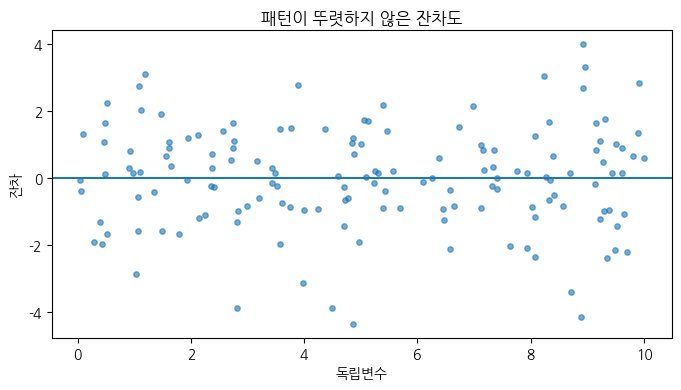

In [187]:
# 선형성과 등분산성에 가까운 예시 데이터
x_ok = np.random.uniform(0, 10, 150)
y_ok = 2 * x_ok + 3 + np.random.normal(0, 1.5, 150)

prediction_ok = np.poly1d(
    np.polyfit(x_ok, y_ok, 1)
)(x_ok)
residual_ok = y_ok - prediction_ok

plt.scatter(x_ok, residual_ok, s=15, alpha=0.6)
plt.axhline(0)
plt.xlabel("독립변수")
plt.ylabel("잔차")
plt.title("패턴이 뚜렷하지 않은 잔차도")
plt.show()


### 7.1 기초 실습: 잔차도 작성

`tips` 데이터에서 `tip ~ total_bill` 단순회귀를 적합한다.

#### 수행 절차

① 회귀식을 적합해 예측값을 계산한다.<br>
② 잔차를 `실제값 - 예측값`으로 계산한다.<br>
③ x축에 예측값, y축에 잔차를 표시한다.<br>
④ 잔차가 0을 중심으로 무작위로 분포하는지 확인한다.


In [188]:
# TODO: polyfit 적합 → 잔차 계산 → 잔차도

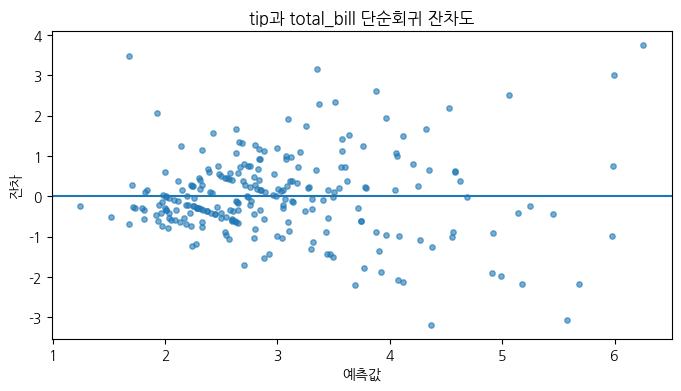

예측값이 커질수록 잔차의 폭이 넓어지는지 확인합니다.


In [189]:
#@title 정답 확인 { display-mode: "form" }
x_bill = tips["total_bill"]
y_tip = tips["tip"]

coef = np.polyfit(x_bill, y_tip, 1)
prediction = np.poly1d(coef)(x_bill)
residual = y_tip - prediction

plt.scatter(prediction, residual, s=15, alpha=0.6)
plt.axhline(0)
plt.xlabel("예측값")
plt.ylabel("잔차")
plt.title("tip과 total_bill 단순회귀 잔차도")
plt.show()

print("예측값이 커질수록 잔차의 폭이 넓어지는지 확인합니다.")


### 7.2 응용 실습: 단순회귀 진단 플롯

`diagnose(x, y)` 함수를 작성해 단순회귀의 주요 가정을 한 번에 확인한다.

| 위치 | 확인 내용 |
|---|---|
| 왼쪽 위 | 산점도와 회귀선으로 선형성 확인 |
| 오른쪽 위 | 예측값과 잔차로 등분산성 확인 |
| 왼쪽 아래 | 잔차 히스토그램으로 정규성 확인 |
| 오른쪽 아래 | Q-Q plot으로 잔차의 꼬리 이탈 확인 |

작성한 함수를 `tips.total_bill`과 `tips.tip`에 적용한다.


In [190]:
def diagnose(x, y):
    # TODO: 2×2 subplot 진단 대시보드
    ...

diagnose(tips["total_bill"], tips["tip"])

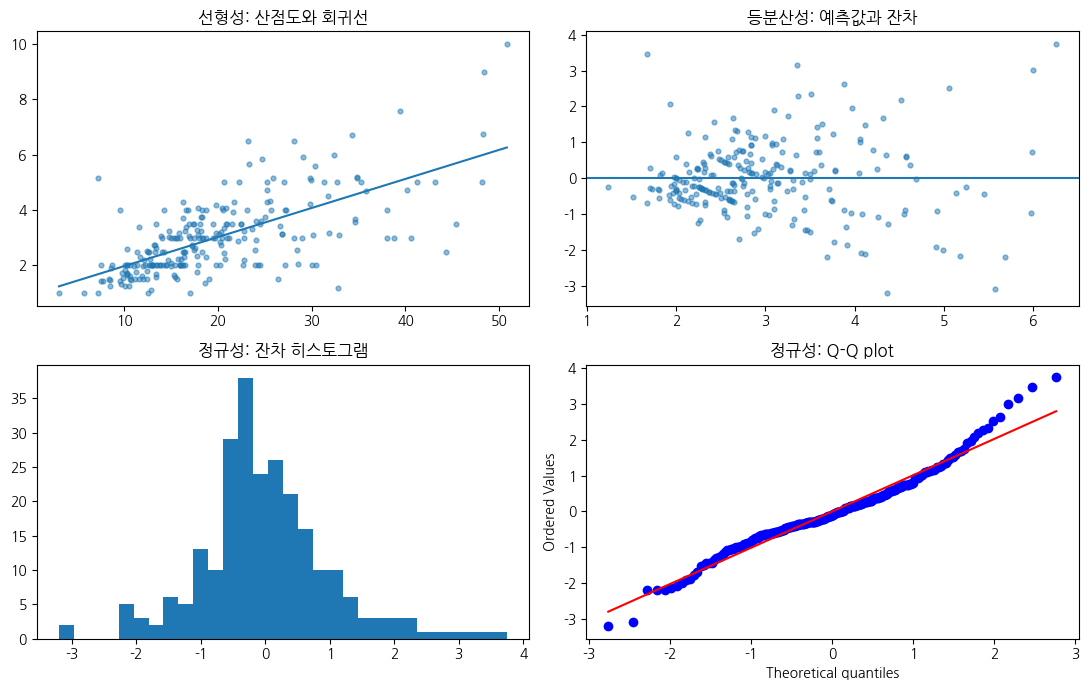

In [191]:
#@title 정답 확인 { display-mode: "form" }
def diagnose(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    coefficient = np.polyfit(x, y, 1)
    prediction = np.poly1d(coefficient)(x)
    residual = y - prediction

    x_sorted = np.sort(x)

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    axes[0, 0].scatter(x, y, s=12, alpha=0.5)
    axes[0, 0].plot(
        x_sorted,
        np.poly1d(coefficient)(x_sorted),
    )
    axes[0, 0].set_title("선형성: 산점도와 회귀선")

    axes[0, 1].scatter(
        prediction,
        residual,
        s=12,
        alpha=0.5,
    )
    axes[0, 1].axhline(0)
    axes[0, 1].set_title("등분산성: 예측값과 잔차")

    axes[1, 0].hist(residual, bins=30)
    axes[1, 0].set_title("정규성: 잔차 히스토그램")

    stats.probplot(residual, plot=axes[1, 1])
    axes[1, 1].set_title("정규성: Q-Q plot")

    plt.tight_layout()
    plt.show()


diagnose(tips["total_bill"], tips["tip"])


### 7.3 심화 실습: 가정 위반 진단과 개선

일부러 가정을 위반한 데이터를 만들고 진단 결과가 어떻게 나타나는지 확인한다.

#### A. 이분산성

`x`가 커질수록 오차의 크기가 증가하는 데이터를 만든다. 원본과 `log(y)` 변환 후의 잔차도를 비교한다.

#### B. 비선형성

`y = 0.5x² + 잡음` 데이터에 1차식과 2차식을 각각 적합한다.<br> 잔차도의 U자 패턴이 2차식에서 줄어드는지 확인한다.

#### C. 다중공선성

서로 거의 같은 `x1`, `x2`와 독립적인 `x3`를 만든다.<br> VIF를 계산하고 `x2`를 제거한 뒤 다시 비교한다.

VIF는 1에 가까울수록 다른 변수와의 중복이 적다.<br> 일반적으로 5를 넘으면 주의하고 10을 넘으면 심각한 다중공선성을 의심한다.


In [192]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# TODO (A): 이분산 생성 → 진단 → log 변환 비교
# TODO (B): 비선형 생성 → 1차 vs 2차 잔차도 비교
# TODO (C): 다중공선성 생성 → VIF 계산 → 변수 제거 후 재계산

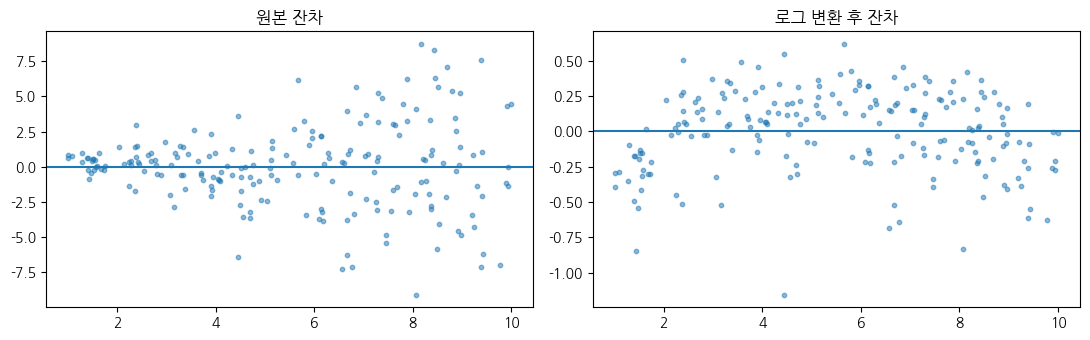

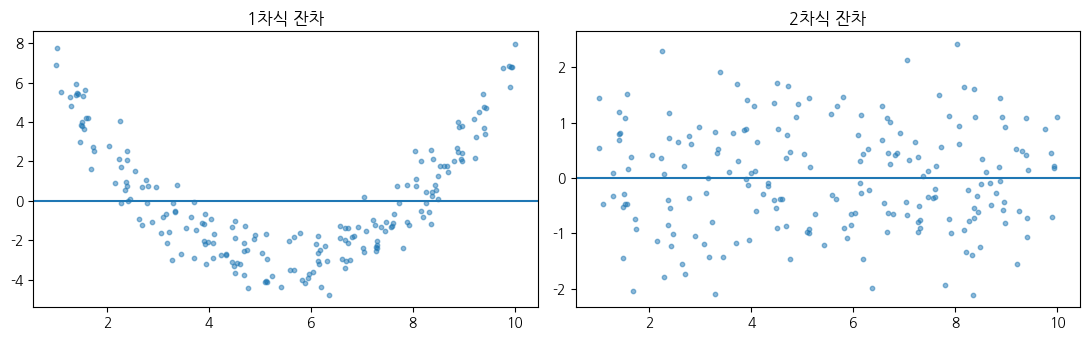

x1과 x2의 상관계수: 0.999

변수 제거 전
x1    370.98
x2    371.00
x3      1.00
Name: VIF, dtype: float64

x2 제거 후
x1    1.0
x3    1.0
Name: VIF, dtype: float64


In [193]:
#@title 정답 확인 { display-mode: "form" }
from statsmodels.stats.outliers_influence import variance_inflation_factor

# A. 이분산성
x = np.random.uniform(1, 10, 200)
y_hetero = 2 * x + np.random.normal(0, 0.5 * x)

y_log = np.log(np.clip(y_hetero, 0.1, None))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, values, title in [
    (axes[0], y_hetero, "원본 잔차"),
    (axes[1], y_log, "로그 변환 후 잔차"),
]:
    prediction = np.poly1d(np.polyfit(x, values, 1))(x)
    residual = values - prediction

    ax.scatter(x, residual, s=10, alpha=0.5)
    ax.axhline(0)
    ax.set_title(title)

plt.tight_layout()
plt.show()

# B. 비선형성
y_nonlinear = 0.5 * x ** 2 + np.random.normal(0, 1, 200)

prediction_linear = np.poly1d(
    np.polyfit(x, y_nonlinear, 1)
)(x)
prediction_quadratic = np.poly1d(
    np.polyfit(x, y_nonlinear, 2)
)(x)

residual_linear = y_nonlinear - prediction_linear
residual_quadratic = y_nonlinear - prediction_quadratic

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, residual, title in [
    (axes[0], residual_linear, "1차식 잔차"),
    (axes[1], residual_quadratic, "2차식 잔차"),
]:
    ax.scatter(x, residual, s=10, alpha=0.5)
    ax.axhline(0)
    ax.set_title(title)

plt.tight_layout()
plt.show()

# C. 다중공선성
x1 = np.random.normal(0, 1, 200)
x2 = x1 + np.random.normal(0, 0.05, 200)
x3 = np.random.normal(0, 1, 200)


def vif_table(df):
    X = sm.add_constant(df)

    values = {
        column: variance_inflation_factor(X.values, index)
        for index, column in enumerate(X.columns)
        if column != "const"
    }

    return pd.Series(values, name="VIF").round(2)


X_all = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "x3": x3,
})

print("x1과 x2의 상관계수:", round(np.corrcoef(x1, x2)[0, 1], 3))
print("\n변수 제거 전")
print(vif_table(X_all))

print("\nx2 제거 후")
print(vif_table(X_all[["x1", "x3"]]))


## 8. 학습 정리

| 주제 | 핵심 내용 |
|---|---|
| 결측치 | 결측 원인을 먼저 확인하고 처리 전후의 분포를 비교한다 |
| 이상치 | 통계 기준으로 후보를 찾고 업무 의미로 최종 판단한다 |
| 스케일링 | 거리 기반 모형에서는 변수의 단위와 범위를 맞춘다 |
| 분포 변환 | 로그, 제곱근과 Box-Cox로 치우친 분포를 완화한다 |
| 인코딩 | 순서가 없으면 One-Hot, 순서가 있으면 의미 있는 값으로 매핑한다 |
| 상관분석 | 상관계수와 산점도를 함께 보고 인과관계로 확대 해석하지 않는다 |
| 회귀분석 | 모형 유의성, 변수 유의성, 설명력과 계수를 순서대로 해석한다 |
| 가정 진단 | 잔차의 패턴과 VIF를 확인하고 모형의 적절성을 점검한다 |

### 제출 전 확인

① 모든 `TODO` 셀을 실행했는가<br>
② 처리 전후의 결과를 비교했는가<br>
③ 그래프와 통계값을 한 문장으로 해석했는가<br>
④ 심화 실습은 선택해서 수행했는가

### 자율 과제

Day 1의 `eda_report()`와 Day 2의 `diagnose()`를 결합해 데이터 구조, 결측치, 분포, 상관관계와 회귀 잔차를 확인하는 분석 함수로 확장한다.
